Enter the name of the CSV file:  crime.csv



Menu:
1. Display Crime Report
2. Display Crimes by Beat
3. Create Bar Chart
4. Quit


Enter your choice (1-4):  1


Crime Report:

Crimes grouped by NCIC code:
0-999: 5
1000-1999: 529
2000-2999: 3216
3000-3999: 369
4000-4999: 98
5000-5999: 864
7000-7999: 2501
8000-8999: 2

Crimes by district:
District 1: 868
District 2: 1462
District 3: 1575
District 4: 1161
District 5: 1159
District 6: 1359

Crimes by beat:
Beat : 42
Beat 1A: 307
Beat 1B: 307
Beat 1C: 253
Beat 2A: 450
Beat 2B: 521
Beat 2C: 485
Beat 3A: 380
Beat 3B: 349
Beat 3C: 491
Beat 3M: 352
Beat 4A: 344
Beat 4B: 400
Beat 4C: 395
Beat 5A: 344
Beat 5B: 397
Beat 5C: 434
Beat 6A: 464
Beat 6B: 412
Beat 6C: 457
Data saved to January.json

Menu:
1. Display Crime Report
2. Display Crimes by Beat
3. Create Bar Chart
4. Quit


Enter your choice (1-4):  2
Enter beat number ensure the letter attached is in uppercase:  5C


Crimes in Beat 5C:
Date: 1/1/2006 0:01, Crime: 459 PC  BURGLARY VEHICLE
Date: 1/1/2006 0:01, Crime: TRAFFIC - I RPT
Date: 1/1/2006 0:30, Crime: 10851(A)VC TAKE VEH W/O OWNER
Date: 1/1/2006 1:30, Crime: 243(D) PC BATT/CIVILIAN W/INJ
Date: 1/1/2006 1:30, Crime: 10851(A)VC TAKE VEH W/O OWNER
Date: 1/1/2006 4:00, Crime: 459 PC  BURGLARY VEHICLE
Date: 1/1/2006 10:00, Crime: THREATS - I RPT
Date: 1/1/2006 11:30, Crime: MISSING PERSON
Date: 1/1/2006 16:00, Crime: 487(A) PC GRAND THEFT
Date: 1/1/2006 16:57, Crime: 11364 HS POSS DRUG PARAPH
Date: 1/1/2006 19:00, Crime: 10851(A)VC TAKE VEH W/O OWNER
Date: 1/1/2006 22:30, Crime: 11364 HS POSS DRUG PARAPH
Date: 1/1/2006 23:20, Crime: 10851(A)VC TAKE VEH W/O OWNER
Date: 1/2/2006 1:56, Crime: TRAFFIC-ACCIDENT-NON INJURY
Date: 1/2/2006 2:00, Crime: 594(B)(1)PC  VANDALISM +$400
Date: 1/2/2006 14:21, Crime: 20002(A) HIT/RUN
Date: 1/2/2006 16:44, Crime: TRAFFIC-ACCIDENT INJURY
Date: 1/2/2006 17:00, Crime: 594(B)(2)(A) VANDALISM/ -$400
Date: 1/2/2006 21:

Enter your choice (1-4):  3
Enter NCIC code 1:  2404
Enter NCIC code 2:  7000
Enter NCIC code 3:  2299
Enter NCIC code 4:  2999
Enter NCIC code 5:  3599
Enter chart title:  Crime by NCIC Code


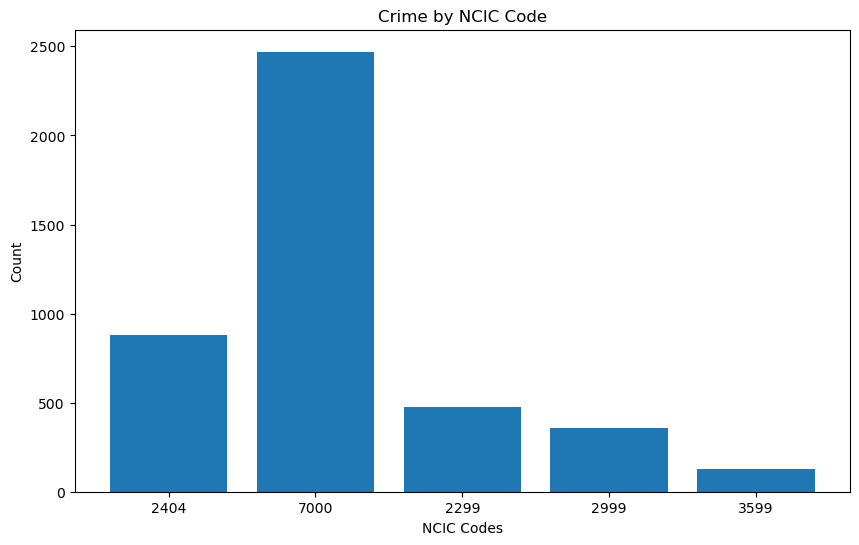


Menu:
1. Display Crime Report
2. Display Crimes by Beat
3. Create Bar Chart
4. Quit


Enter your choice (1-4):  4


Exiting program.


In [3]:
##Importing all the json and csv and matplotlib libraries 
import csv
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Function to read csv file and create a dictionary called data
def read_csv_file(filename):
#Read and return data from the CSV file crime.csv
    data = []
    with open(filename, 'r') as file:
        csv_reader = csv.DictReader(file)
        for row in csv_reader:
            data.append(row)
    return data

def display_crime_report(data):
#Displaying crime report with specified groupings
    ncic_groups = {}
    district_counts = {}
    beat_counts = {}

    for row in data:
        # Grouping by NCIC code
        ncic_code = int(row['ucr_ncic_code'])
        group = (ncic_code // 1000) * 1000
        ncic_groups[group] = ncic_groups.get(group, 0) + 1

        # Count by district
        district = row['district']
        district_counts[district] = district_counts.get(district, 0) + 1

        # Count by beat
        beat = row['beat'].strip()
        beat_counts[beat] = beat_counts.get(beat, 0) + 1
# Print counts of crimes grouped by NCIC code ranges, districts, and beats
    print("Crime Report:")
    print("\nCrimes grouped by NCIC code:")
    for group, count in sorted(ncic_groups.items()):
        print(f"{group}-{group+999}: {count}")

    print("\nCrimes by district:")
    for district, count in sorted(district_counts.items()):
        print(f"District {district}: {count}")

    print("\nCrimes by beat:")
    for beat, count in sorted(beat_counts.items()):
        print(f"Beat {beat}: {count}")
# Return a dictionary containing the grouped data for JSON serialization
    return {
        "ncic_groups": ncic_groups,
        "district_counts": district_counts,
        "beat_counts": beat_counts
    }
# saving file to json
def save_to_json(data, filename):
    """Save data to a JSON file."""
    with open(filename, 'w') as file:
        json.dump(data, file, indent=4)
    print(f"Data saved to {filename}")
# displaying crimes by beat by looping through the entire data
def display_crimes_by_beat(data, beat):
    """Display all crimes for a specific beat."""
    print(f"Crimes in Beat {beat}:")
    for row in data:
        if row['beat'].strip() == beat:
            print(f"Date: {row['cdatetime']}, Crime: {row['crimedescr']}")
# displaying bar chart by user inputed NCIC codes
def create_bar_chart(data, ncic_codes, title):
    """Create and save a bar chart for specified NCIC codes."""
    counts = {code: sum(1 for row in data if row['ucr_ncic_code'] == code) for code in ncic_codes}
    
    plt.figure(figsize=(10, 6))
    plt.bar(counts.keys(), counts.values())
    plt.title(title)
    plt.xlabel('NCIC Codes')
    plt.ylabel('Count')
    plt.savefig(f"{title}.png")
    plt.show()
# Requiring user input to access the name of the csv file
def main():
    filename = input("Enter the name of the CSV file: ")
    data = read_csv_file(filename)

    while True:
        print("\nMenu:")
        print("1. Display Crime Report")
        print("2. Display Crimes by Beat")
        print("3. Create Bar Chart")
        print("4. Quit")

        choice = input("Enter your choice (1-4): ")

        if choice == '1':
            report_data = display_crime_report(data)
            month = datetime.now().strftime("%B")
            save_to_json(report_data, f"{month}.json")
        elif choice == '2':
            beat = input("Enter beat number ensure the letter attached is in uppercase: ")
            display_crimes_by_beat(data, beat)
        elif choice == '3':
            ncic_codes = [input(f"Enter NCIC code {i+1}: ") for i in range(5)]
            title = input("Enter chart title: ")
            create_bar_chart(data, ncic_codes, title)
        elif choice == '4':
            print("Exiting program.")
            break
        else:
            print("Invalid choice. Please try again.")

if __name__ == "__main__":
    main()